In [ ]:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
mnist=fetch_openml('mnist_784',version=1)

In [ ]:
X,y=mnist['data'],mnist['target']
X.shape

(70000, 784)

In [ ]:
y

0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Name: class, Length: 70000, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

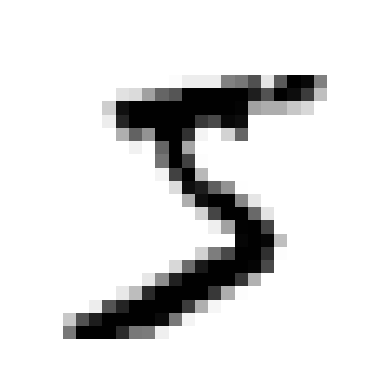

In [ ]:
some_digit = X.iloc[0]

some_digit_image = some_digit.values.reshape(28, 28)
plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()


In [ ]:
y[0]

'5'

In [ ]:
y=y.astype(np.uint8)

In [ ]:
X_train,X_test,y_train,y_test=X[:6000],X[6000:],y[:6000],y[6000:]

In [ ]:
y_test_5=(y_test==5)
y_train_5=(y_train==5)

In [ ]:
from sklearn.linear_model import SGDClassifier
sgd=SGDClassifier(random_state=42)
sgd.fit(X_train,y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [ ]:
sgd.predict([some_digit])

C:\Users\Anant Jain\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([ True])

In [ ]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd,X_train,y_train_5,cv=3,scoring='accuracy')

array([0.962 , 0.956 , 0.9665])

In [ ]:
from sklearn.base import BaseEstimator
class Not_5(BaseEstimator):
  def fit(self,x,y=None):
    return self
  def predict(self,x):
    return np.zeros((len(x),1),dtype=bool)

In [ ]:
not5=Not_5()
cross_val_score(not5,X_train,y_train_5,cv=3,scoring='accuracy')

array([0.91 , 0.915, 0.918])

In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_pred=cross_val_predict(sgd,X_train,y_train_5,cv=3)

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5,y_train_pred)

array([[5375,  111],
       [ 120,  394]])

In [ ]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_5,y_train_pred)


0.7801980198019802

In [ ]:
recall_score(y_train_5,y_train_pred)

0.7665369649805448

In [ ]:
from sklearn.metrics import f1_score
f1_score(y_train_5,y_train_pred)

0.7733071638861629

In [ ]:
y_scores = cross_val_predict(sgd, X_train, y_train_5, cv=3,method="decision_function")


In [ ]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)



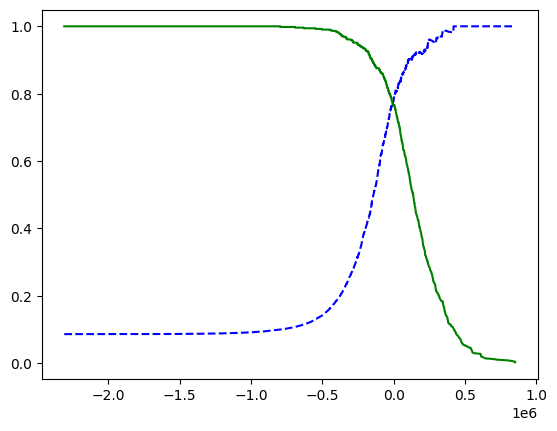

In [ ]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
 plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
 plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)

In [ ]:
from sklearn.metrics import roc_curve
fpr,tpr,thresh=roc_curve(y_train_5,y_scores)

In [ ]:
def plot_roc_curve(fpr,tpr,label=None):
  plt.plot(fpr,tpr,linewidth=2,label=label)
  plt.plot([0,1],[0,1],'k--')
  [...]


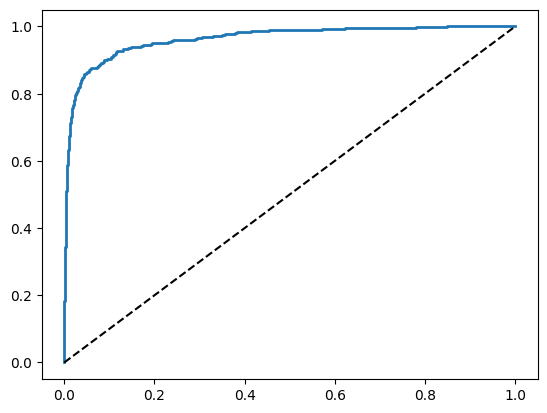

In [ ]:
plot_roc_curve(fpr,tpr)

In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5,y_scores)

0.9641599203348885